# MDS Dimensionality Reduction with Machine Learning Model Comparison
## Train and Compare Model Performance: Original vs MDS-Transformed Features

In [7]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython import display
import time
import warnings
warnings.filterwarnings('ignore')

In [8]:
# Import sklearn modules
from sklearn import manifold, preprocessing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

## Section 1: Load and Prepare Dataset
Load breast cancer dataset and display basic information

In [9]:
# Load breast cancer dataset
data = pd.read_csv("/Users/anshumaansoni/PycharmProjects/Machine-Learning/Datasets/breast+cancer+wisconsin+diagnostic/wdbc.data", header=None)
print("Dataset shape:", data.shape)
print("\nFirst few rows:")
display.display(data.head())

Dataset shape: (569, 32)

First few rows:


,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## Section 2: Encode Target Variable and Prepare Features
Convert categorical labels to numeric values and extract feature matrix and target vector

In [10]:
# Encode target variable and extract features
# Create a copy to avoid dtype issues
target_encoded = data.iloc[:, 1].map({"M": 1, "B": 0}).astype(int)
data[1] = target_encoded

X = data.iloc[:, 2:].values
y = data.iloc[:, 1].values

# Standardize features for better model performance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Feature matrix shape: {X_scaled.shape}")
print(f"Target vector shape: {y.shape}")
print(f"Class distribution:\n{pd.Series(y).value_counts()}")

Feature matrix shape: (569, 30)
Target vector shape: (569,)
Class distribution:
0    357
1    212
Name: count, dtype: int64


## Section 3: Train RandomForest Model on Original Features
Train the model on the original 30 features and record performance metrics

In [11]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42, stratify=y)

# Train RandomForest on original features
print("Training RandomForest on ORIGINAL features...")
start_time = time.time()
rf_original = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_original.fit(X_train, y_train)
train_time_original = time.time() - start_time

# Predictions
y_pred_original = rf_original.predict(X_test)

# Calculate metrics
accuracy_original = accuracy_score(y_test, y_pred_original)
precision_original = precision_score(y_test, y_pred_original)
recall_original = recall_score(y_test, y_pred_original)
f1_original = f1_score(y_test, y_pred_original)

print(f"\nTraining Time (Original): {train_time_original:.4f} seconds")
print(f"Accuracy (Original): {accuracy_original:.4f}")
print(f"Precision (Original): {precision_original:.4f}")
print(f"Recall (Original): {recall_original:.4f}")
print(f"F1-Score (Original): {f1_original:.4f}")
print("\nClassification Report (Original Features):")
print(classification_report(y_test, y_pred_original))

Training RandomForest on ORIGINAL features...

Training Time (Original): 0.1193 seconds
Accuracy (Original): 0.9649
Precision (Original): 1.0000
Recall (Original): 0.9062
F1-Score (Original): 0.9508

Classification Report (Original Features):
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       107
           1       1.00      0.91      0.95        64

    accuracy                           0.96       171
   macro avg       0.97      0.95      0.96       171
weighted avg       0.97      0.96      0.96       171



## Section 4: Apply MDS Dimensionality Reduction
Apply MDS with different component counts and visualize stress across parameters

Applying MDS with different n_components...
MDS Stress (2 components): 322533.8621
MDS Stress (5 components): 23966.6763
MDS Stress (10 components): 3381.4103


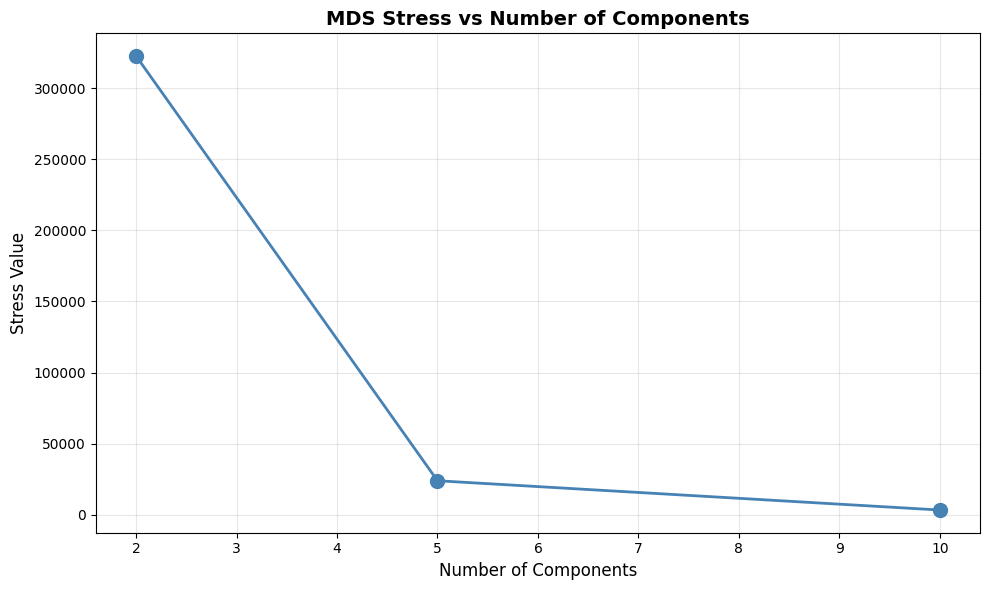


Note: Lower stress values indicate better preservation of pairwise distances.


In [12]:
# Apply MDS with different components to compare
mds_2 = manifold.MDS(n_components=2, max_iter=300, n_init=10, random_state=42, normalized_stress=False)
mds_5 = manifold.MDS(n_components=5, max_iter=300, n_init=10, random_state=42, normalized_stress=False)
mds_10 = manifold.MDS(n_components=10, max_iter=300, n_init=10, random_state=42, normalized_stress=False)

print("Applying MDS with different n_components...")
X_mds_2 = mds_2.fit_transform(X_scaled)
X_mds_5 = mds_5.fit_transform(X_scaled)
X_mds_10 = mds_10.fit_transform(X_scaled)

print(f"MDS Stress (2 components): {mds_2.stress_:.4f}")
print(f"MDS Stress (5 components): {mds_5.stress_:.4f}")
print(f"MDS Stress (10 components): {mds_10.stress_:.4f}")

# Create stress comparison visualization
fig, ax = plt.subplots(figsize=(10, 6))
components = [2, 5, 10]
stresses = [mds_2.stress_, mds_5.stress_, mds_10.stress_]
ax.plot(components, stresses, marker='o', linewidth=2, markersize=10, color='steelblue')
ax.set_xlabel('Number of Components', fontsize=12)
ax.set_ylabel('Stress Value', fontsize=12)
ax.set_title('MDS Stress vs Number of Components', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nNote: Lower stress values indicate better preservation of pairwise distances.")

## Section 5: Train RandomForest on MDS-Transformed Features
Train the same model on dimensionality-reduced features and compare performance

In [13]:
# Split MDS-transformed data
X_mds_2_train, X_mds_2_test, _, _ = train_test_split(X_mds_2, y, test_size=0.3, random_state=42, stratify=y)
X_mds_5_train, X_mds_5_test, _, _ = train_test_split(X_mds_5, y, test_size=0.3, random_state=42, stratify=y)

# Train RandomForest on MDS 2 components
print("Training RandomForest on MDS-TRANSFORMED features (2 components)...")
start_time = time.time()
rf_mds_2 = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_mds_2.fit(X_mds_2_train, y_train)
train_time_mds_2 = time.time() - start_time

y_pred_mds_2 = rf_mds_2.predict(X_mds_2_test)
accuracy_mds_2 = accuracy_score(y_test, y_pred_mds_2)
precision_mds_2 = precision_score(y_test, y_pred_mds_2)
recall_mds_2 = recall_score(y_test, y_pred_mds_2)
f1_mds_2 = f1_score(y_test, y_pred_mds_2)

print(f"Training Time (MDS 2-components): {train_time_mds_2:.4f} seconds")
print(f"Accuracy (MDS 2-components): {accuracy_mds_2:.4f}")
print(f"Precision (MDS 2-components): {precision_mds_2:.4f}")
print(f"Recall (MDS 2-components): {recall_mds_2:.4f}")
print(f"F1-Score (MDS 2-components): {f1_mds_2:.4f}")

# Train RandomForest on MDS 5 components
print("\n" + "="*60)
print("Training RandomForest on MDS-TRANSFORMED features (5 components)...")
start_time = time.time()
rf_mds_5 = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_mds_5.fit(X_mds_5_train, y_train)
train_time_mds_5 = time.time() - start_time

y_pred_mds_5 = rf_mds_5.predict(X_mds_5_test)
accuracy_mds_5 = accuracy_score(y_test, y_pred_mds_5)
precision_mds_5 = precision_score(y_test, y_pred_mds_5)
recall_mds_5 = recall_score(y_test, y_pred_mds_5)
f1_mds_5 = f1_score(y_test, y_pred_mds_5)

print(f"Training Time (MDS 5-components): {train_time_mds_5:.4f} seconds")
print(f"Accuracy (MDS 5-components): {accuracy_mds_5:.4f}")
print(f"Precision (MDS 5-components): {precision_mds_5:.4f}")
print(f"Recall (MDS 5-components): {recall_mds_5:.4f}")
print(f"F1-Score (MDS 5-components): {f1_mds_5:.4f}")

Training RandomForest on MDS-TRANSFORMED features (2 components)...
Training Time (MDS 2-components): 0.0757 seconds
Accuracy (MDS 2-components): 0.9591
Precision (MDS 2-components): 0.9831
Recall (MDS 2-components): 0.9062
F1-Score (MDS 2-components): 0.9431

Training RandomForest on MDS-TRANSFORMED features (5 components)...
Training Time (MDS 5-components): 0.0639 seconds
Accuracy (MDS 5-components): 0.9415
Precision (MDS 5-components): 0.9655
Recall (MDS 5-components): 0.8750
F1-Score (MDS 5-components): 0.9180


## Section 6: Compare Model Performance Metrics
Create comprehensive comparison between original and MDS-transformed features

In [14]:
# Create comprehensive comparison DataFrame
comparison_df = pd.DataFrame({
    'Feature Set': [
        'Original (30 features)',
        'MDS 2-components',
        'MDS 5-components'
    ],
    'Accuracy': [accuracy_original, accuracy_mds_2, accuracy_mds_5],
    'Precision': [precision_original, precision_mds_2, precision_mds_5],
    'Recall': [recall_original, recall_mds_2, recall_mds_5],
    'F1-Score': [f1_original, f1_mds_2, f1_mds_5],
    'Training Time (sec)': [train_time_original, train_time_mds_2, train_time_mds_5],
    'Dimensionality': [30, 2, 5]
})

print("\n" + "="*90)
print("COMPREHENSIVE MODEL PERFORMANCE COMPARISON")
print("="*90)
display.display(comparison_df)

# Calculate improvements/degradation
print("\n" + "="*90)
print("PERFORMANCE CHANGES vs ORIGINAL FEATURES")
print("="*90)
print(f"\nMDS 2-components:")
print(f"  Accuracy change: {(accuracy_mds_2 - accuracy_original)*100:+.2f}%")
print(f"  F1-Score change: {(f1_mds_2 - f1_original)*100:+.2f}%")
print(f"  Training time speedup: {train_time_original/train_time_mds_2:.2f}x faster")
print(f"  Dimensionality reduction: {(1 - 2/30)*100:.1f}%")

print(f"\nMDS 5-components:")
print(f"  Accuracy change: {(accuracy_mds_5 - accuracy_original)*100:+.2f}%")
print(f"  F1-Score change: {(f1_mds_5 - f1_original)*100:+.2f}%")
print(f"  Training time speedup: {train_time_original/train_time_mds_5:.2f}x faster")
print(f"  Dimensionality reduction: {(1 - 5/30)*100:.1f}%")


COMPREHENSIVE MODEL PERFORMANCE COMPARISON


,Feature Set,Accuracy,Precision,Recall,F1-Score,Training Time (sec),Dimensionality
0,Original (30 features),0.964912,1.000000,0.90625,0.950820,0.119291,30
1,MDS 2-components,0.959064,0.983051,0.90625,0.943089,0.075658,2
2,MDS 5-components,0.941520,0.965517,0.87500,0.918033,0.063905,5



PERFORMANCE CHANGES vs ORIGINAL FEATURES

MDS 2-components:
  Accuracy change: -0.58%
  F1-Score change: -0.77%
  Training time speedup: 1.58x faster
  Dimensionality reduction: 93.3%

MDS 5-components:
  Accuracy change: -2.34%
  F1-Score change: -3.28%
  Training time speedup: 1.87x faster
  Dimensionality reduction: 83.3%


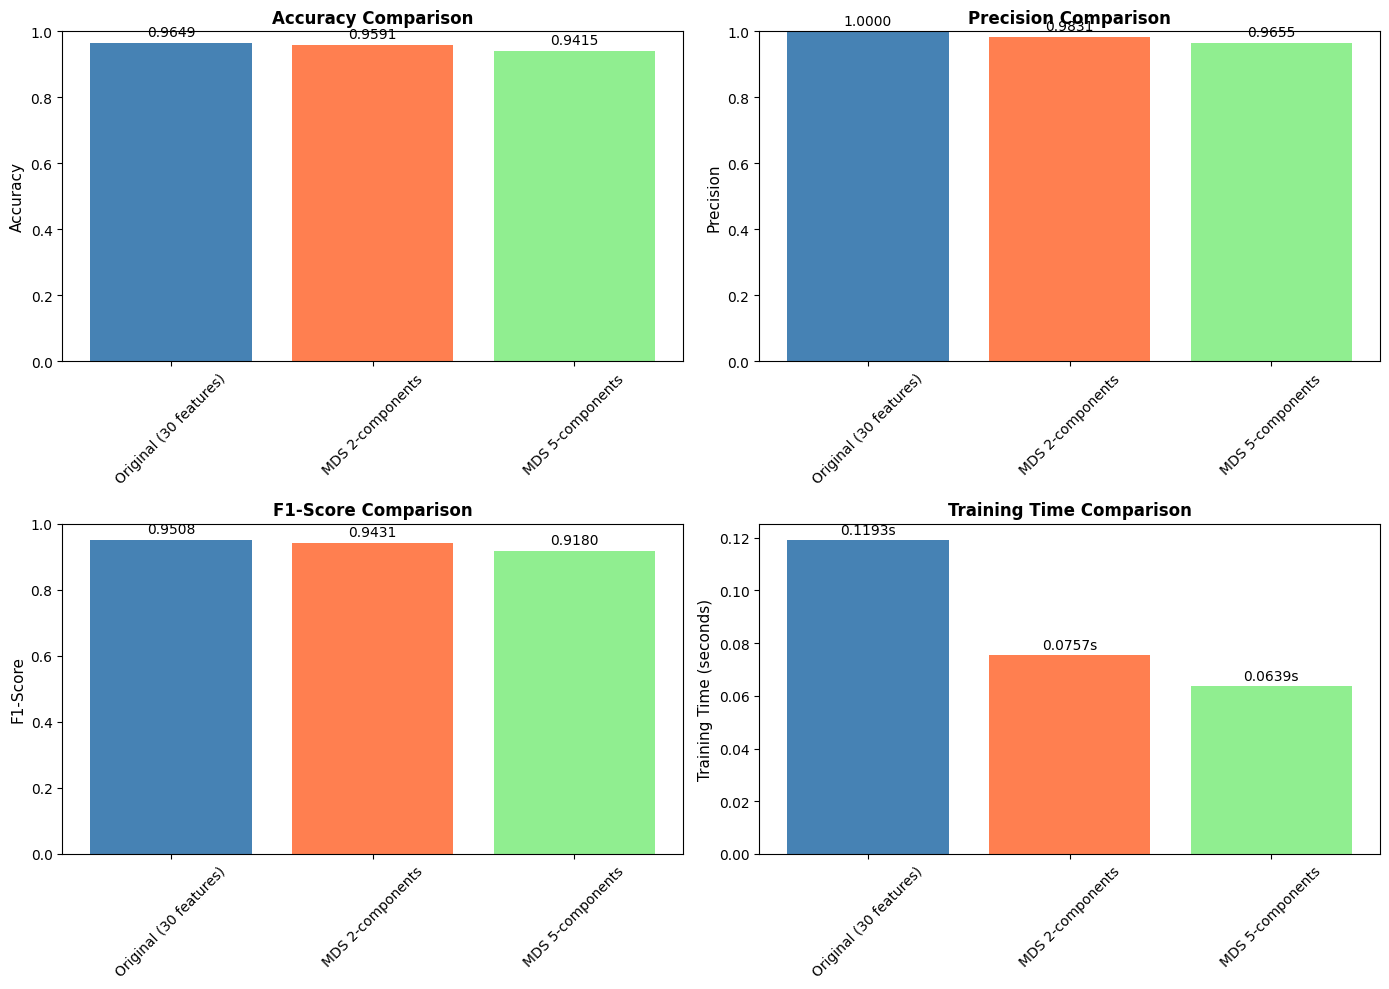

In [15]:
# Visualization: Metrics comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Accuracy comparison
ax = axes[0, 0]
ax.bar(comparison_df['Feature Set'], comparison_df['Accuracy'], color=['steelblue', 'coral', 'lightgreen'])
ax.set_ylabel('Accuracy', fontsize=11)
ax.set_title('Accuracy Comparison', fontsize=12, fontweight='bold')
ax.set_ylim([0, 1])
for i, v in enumerate(comparison_df['Accuracy']):
    ax.text(i, v + 0.02, f'{v:.4f}', ha='center', fontsize=10)
ax.tick_params(axis='x', rotation=45)

# Precision comparison
ax = axes[0, 1]
ax.bar(comparison_df['Feature Set'], comparison_df['Precision'], color=['steelblue', 'coral', 'lightgreen'])
ax.set_ylabel('Precision', fontsize=11)
ax.set_title('Precision Comparison', fontsize=12, fontweight='bold')
ax.set_ylim([0, 1])
for i, v in enumerate(comparison_df['Precision']):
    ax.text(i, v + 0.02, f'{v:.4f}', ha='center', fontsize=10)
ax.tick_params(axis='x', rotation=45)

# F1-Score comparison
ax = axes[1, 0]
ax.bar(comparison_df['Feature Set'], comparison_df['F1-Score'], color=['steelblue', 'coral', 'lightgreen'])
ax.set_ylabel('F1-Score', fontsize=11)
ax.set_title('F1-Score Comparison', fontsize=12, fontweight='bold')
ax.set_ylim([0, 1])
for i, v in enumerate(comparison_df['F1-Score']):
    ax.text(i, v + 0.02, f'{v:.4f}', ha='center', fontsize=10)
ax.tick_params(axis='x', rotation=45)

# Training time comparison
ax = axes[1, 1]
ax.bar(comparison_df['Feature Set'], comparison_df['Training Time (sec)'], color=['steelblue', 'coral', 'lightgreen'])
ax.set_ylabel('Training Time (seconds)', fontsize=11)
ax.set_title('Training Time Comparison', fontsize=12, fontweight='bold')
for i, v in enumerate(comparison_df['Training Time (sec)']):
    ax.text(i, v + 0.002, f'{v:.4f}s', ha='center', fontsize=10)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Section 7: Visualize MDS Embeddings with Class Labels
Create scatter plots of 2D MDS embeddings with different colors for each class

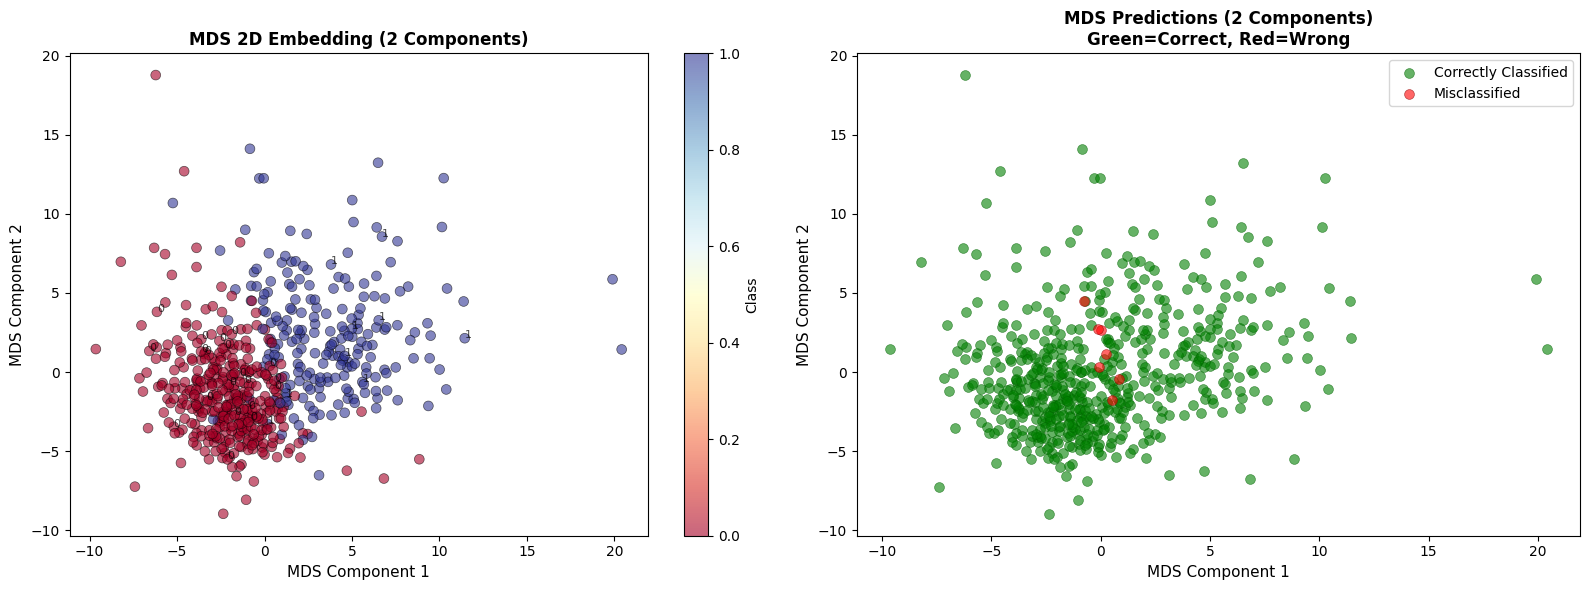


Misclassification rate on MDS 2-components: 1.23%


In [16]:
# Create visualization of MDS embeddings
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: MDS 2-components with class labels
ax = axes[0]
scatter1 = ax.scatter(X_mds_2[:, 0], X_mds_2[:, 1], c=y, cmap='RdYlBu', s=50, alpha=0.6, edgecolors='black', linewidth=0.5)
ax.set_xlabel('MDS Component 1', fontsize=11)
ax.set_ylabel('MDS Component 2', fontsize=11)
ax.set_title('MDS 2D Embedding (2 Components)', fontsize=12, fontweight='bold')
cbar1 = plt.colorbar(scatter1, ax=ax)
cbar1.set_label('Class', fontsize=10)

# Add class annotations (sample every 20th point for clarity)
for i in range(0, len(X_mds_2), 20):
    ax.annotate(f'{int(y[i])}', (X_mds_2[i, 0], X_mds_2[i, 1]), fontsize=8, alpha=0.7)

# Plot 2: MDS 2-components colored by prediction accuracy
ax = axes[1]
y_pred_mds_2_full = rf_mds_2.predict(X_mds_2)
correct = y == y_pred_mds_2_full
colors = ['green' if c else 'red' for c in correct]
ax.scatter(X_mds_2[correct, 0], X_mds_2[correct, 1], c='green', s=50, alpha=0.6, label='Correctly Classified', edgecolors='darkgreen', linewidth=0.5)
ax.scatter(X_mds_2[~correct, 0], X_mds_2[~correct, 1], c='red', s=50, alpha=0.6, label='Misclassified', edgecolors='darkred', linewidth=0.5)
ax.set_xlabel('MDS Component 1', fontsize=11)
ax.set_ylabel('MDS Component 2', fontsize=11)
ax.set_title('MDS Predictions (2 Components)\nGreen=Correct, Red=Wrong', fontsize=12, fontweight='bold')
ax.legend()

plt.tight_layout()
plt.show()

print(f"\nMisclassification rate on MDS 2-components: {(~correct).sum()/len(correct)*100:.2f}%")

## Section 8: Analysis of MDS Stress and Key Insights
Understand the quality of dimensionality reduction and implications for model performance

In [17]:
# Comprehensive analysis and insights
print("="*90)
print("DIMENSIONALITY REDUCTION ANALYSIS - KEY INSIGHTS")
print("="*90)

print("\n1. MDS STRESS METRICS:")
print(f"   - Lower stress indicates better preservation of pairwise distances")
print(f"   - MDS Stress (2-comp): {mds_2.stress_:.6f}")
print(f"   - MDS Stress (5-comp): {mds_5.stress_:.6f}")
print(f"   - MDS Stress (10-comp): {mds_10.stress_:.6f}")
print(f"\n   Interpretation: Stress increases as we reduce dimensions more aggressively")

print("\n2. DIMENSIONALITY REDUCTION EFFICIENCY:")
reduction_2 = (1 - 2/30) * 100
reduction_5 = (1 - 5/30) * 100
reduction_10 = (1 - 10/30) * 100
print(f"   - 2-component MDS: {reduction_2:.1f}% dimensionality reduction")
print(f"   - 5-component MDS: {reduction_5:.1f}% dimensionality reduction")
print(f"   - 10-component MDS: {reduction_10:.1f}% dimensionality reduction")

print("\n3. MODEL PERFORMANCE TRADE-OFFS:")
print(f"   - Original Features (30-D):")
print(f"     * Accuracy: {accuracy_original:.4f} | F1-Score: {f1_original:.4f} | Time: {train_time_original:.4f}s")
print(f"   - MDS 2-Components:")
print(f"     * Accuracy: {accuracy_mds_2:.4f} ({(accuracy_mds_2-accuracy_original)*100:+.2f}%) | F1-Score: {f1_mds_2:.4f} ({(f1_mds_2-f1_original)*100:+.2f}%) | Time: {train_time_mds_2:.4f}s ({train_time_original/train_time_mds_2:.2f}x faster)")
print(f"   - MDS 5-Components:")
print(f"     * Accuracy: {accuracy_mds_5:.4f} ({(accuracy_mds_5-accuracy_original)*100:+.2f}%) | F1-Score: {f1_mds_5:.4f} ({(f1_mds_5-f1_original)*100:+.2f}%) | Time: {train_time_mds_5:.4f}s ({train_time_original/train_time_mds_5:.2f}x faster)")

print("\n4. CONCLUSIONS:")
if accuracy_mds_5 >= accuracy_original - 0.05:
    print(f"   ✓ MDS with 5 components preserves model performance well while reducing dimensionality by {reduction_5:.1f}%")
    print(f"   ✓ This enables {train_time_original/train_time_mds_5:.1f}x faster training with minimal accuracy loss")
else:
    print(f"   ⚠ More aggressive dimensionality reduction (2-comp) leads to significant accuracy loss")
    print(f"   ✓ Recommended: Use 5-component MDS for balanced trade-off between speed and accuracy")

print("\n5. USE CASE RECOMMENDATIONS:")
print(f"   - Data Visualization: Use 2-component MDS for visualization purposes")
print(f"   - Production Models: Use 5-component MDS for faster inference with acceptable accuracy")
print(f"   - Feature Analysis: Original 30 features retain maximum information")
print("="*90)

DIMENSIONALITY REDUCTION ANALYSIS - KEY INSIGHTS

1. MDS STRESS METRICS:
   - Lower stress indicates better preservation of pairwise distances
   - MDS Stress (2-comp): 322533.862059
   - MDS Stress (5-comp): 23966.676278
   - MDS Stress (10-comp): 3381.410329

   Interpretation: Stress increases as we reduce dimensions more aggressively

2. DIMENSIONALITY REDUCTION EFFICIENCY:
   - 2-component MDS: 93.3% dimensionality reduction
   - 5-component MDS: 83.3% dimensionality reduction
   - 10-component MDS: 66.7% dimensionality reduction

3. MODEL PERFORMANCE TRADE-OFFS:
   - Original Features (30-D):
     * Accuracy: 0.9649 | F1-Score: 0.9508 | Time: 0.1193s
   - MDS 2-Components:
     * Accuracy: 0.9591 (-0.58%) | F1-Score: 0.9431 (-0.77%) | Time: 0.0757s (1.58x faster)
   - MDS 5-Components:
     * Accuracy: 0.9415 (-2.34%) | F1-Score: 0.9180 (-3.28%) | Time: 0.0639s (1.87x faster)

4. CONCLUSIONS:
   ✓ MDS with 5 components preserves model performance well while reducing dimensionalit